In [28]:
#Reading the Customer Churn CSV file
import pandas as pd
df = pd.read_csv('Customer-Churn-Records.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(10000, 18)
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              

1. Importing Packages

In [29]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)
from imblearn.over_sampling import SMOTE
import joblib
import os

os.makedirs('outputs', exist_ok=True)

2. Loading Dataset

In [30]:
df = pd.read_csv('Customer-Churn-Records.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (10000, 18)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


3. Data Cleaning

In [31]:

print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print(f"\nData Types:\n{df.dtypes}")

# Dropping irrelevant columns
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print(f"Shape after dropping irrelevant columns: {df.shape}")
df.describe()


Missing Values:
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

Duplicate Rows: 0

Data Types:
RowNumber               int64
CustomerId              int64
Surname                   str
CreditScore             int64
Geography                 str
Gender                    str
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type                 

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


EDA 1

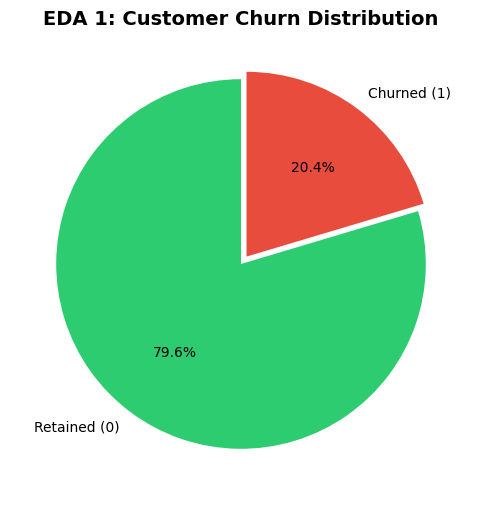

Retained: 7962 | Churned: 2038
Churn Rate: 20.4%


In [32]:
plt.figure(figsize=(8, 6))
churn_counts = df['Exited'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.pie(churn_counts,
        labels=['Retained (0)', 'Churned (1)'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=(0, 0.05))
plt.title('EDA 1: Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.savefig('outputs/eda1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Retained: {churn_counts[0]} | Churned: {churn_counts[1]}")
print(f"Churn Rate: {churn_counts[1]/len(df)*100:.1f}%")

EDA: 2

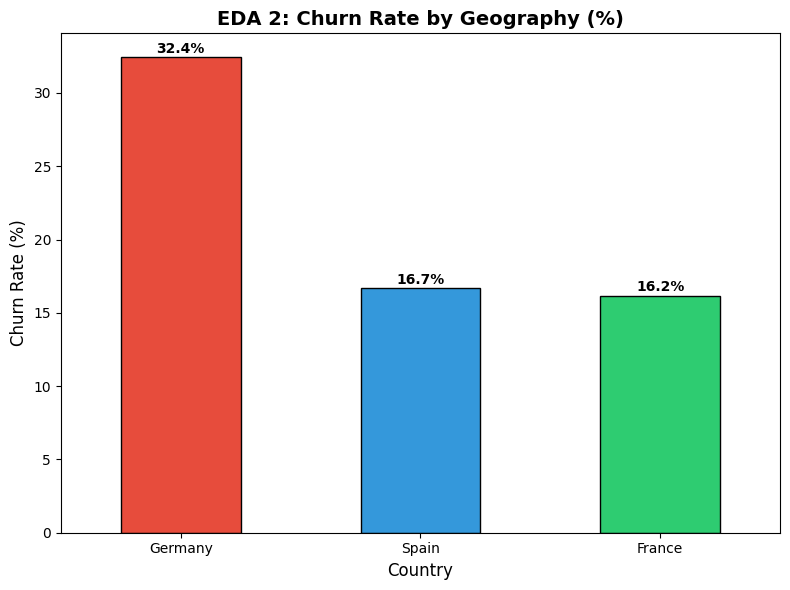

Geography
Germany    32.443204
Spain      16.673395
France     16.174711
Name: Exited, dtype: float64


In [33]:
plt.figure(figsize=(8, 6))
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.sort_values(ascending=False).plot(
    kind='bar',
    color=['#e74c3c', '#3498db', '#2ecc71'],
    edgecolor='black')
plt.title('EDA 2: Churn Rate by Geography (%)', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(geo_churn.sort_values(ascending=False)):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda2_churn_by_geography.png', dpi=150, bbox_inches='tight')
plt.show()
print(geo_churn.sort_values(ascending=False))

German customers churn at 32.4%, significantly higher than France (16.2%) and Spain (16.7%), suggesting region-specific dissatisfaction or competitive banking alternatives in Germany.

EDA 3: 

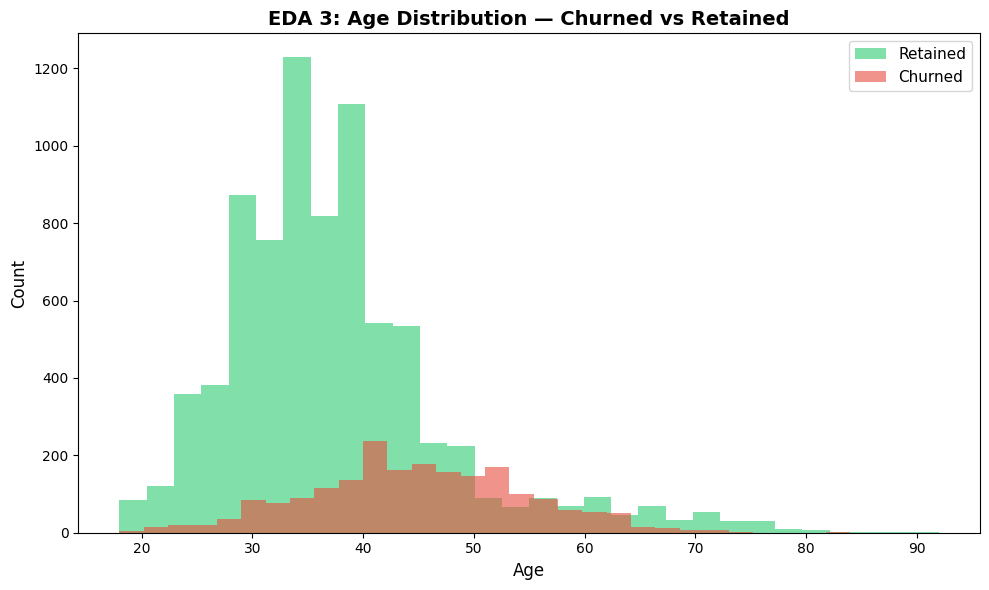

Average age - Retained: 37.4
Average age - Churned:  44.8


In [34]:
plt.figure(figsize=(10, 6))
df[df['Exited'] == 0]['Age'].plot(
    kind='hist', bins=30, alpha=0.6, color='#2ecc71', label='Retained')
df[df['Exited'] == 1]['Age'].plot(
    kind='hist', bins=30, alpha=0.6, color='#e74c3c', label='Churned')
plt.title('EDA 3: Age Distribution — Churned vs Retained',
          fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('outputs/eda3_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Average age - Retained: {df[df['Exited']==0]['Age'].mean():.1f}")
print(f"Average age - Churned:  {df[df['Exited']==1]['Age'].mean():.1f}")

The average age of churned customers (44.8) is notably higher than retained customers (37.4), indicating that older customers are at greater risk of churn, possibly due to better retirement banking offers at competitor banks.

EDA 4:

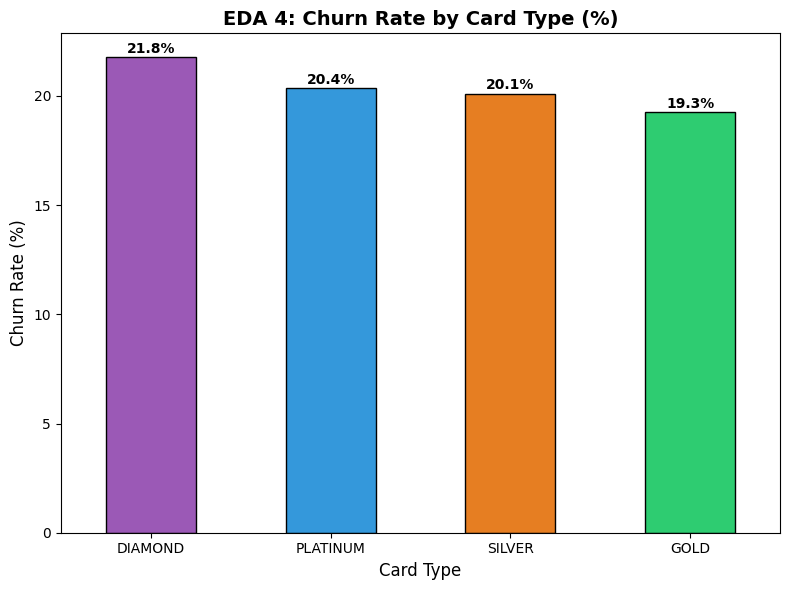

Card Type
DIAMOND     21.779019
PLATINUM    20.360721
SILVER      20.112179
GOLD        19.264588
Name: Exited, dtype: float64


In [35]:
plt.figure(figsize=(8, 6))
card_churn = df.groupby('Card Type')['Exited'].mean() * 100
card_churn.sort_values(ascending=False).plot(
    kind='bar',
    color=['#9b59b6', '#3498db', '#e67e22', '#2ecc71'],
    edgecolor='black')
plt.title('EDA 4: Churn Rate by Card Type (%)', fontsize=14, fontweight='bold')
plt.xlabel('Card Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(card_churn.sort_values(ascending=False)):
    plt.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda4_churn_by_card_type.png', dpi=150, bbox_inches='tight')
plt.show()
print(card_churn.sort_values(ascending=False))

Churn rates are relatively consistent across card types, ranging from 19.3% (Gold) to 21.8% (Diamond), suggesting card type alone is not a strong predictor of churn. This indicates other factors like age, geography and activity status play a bigger role.

EDA 5: 

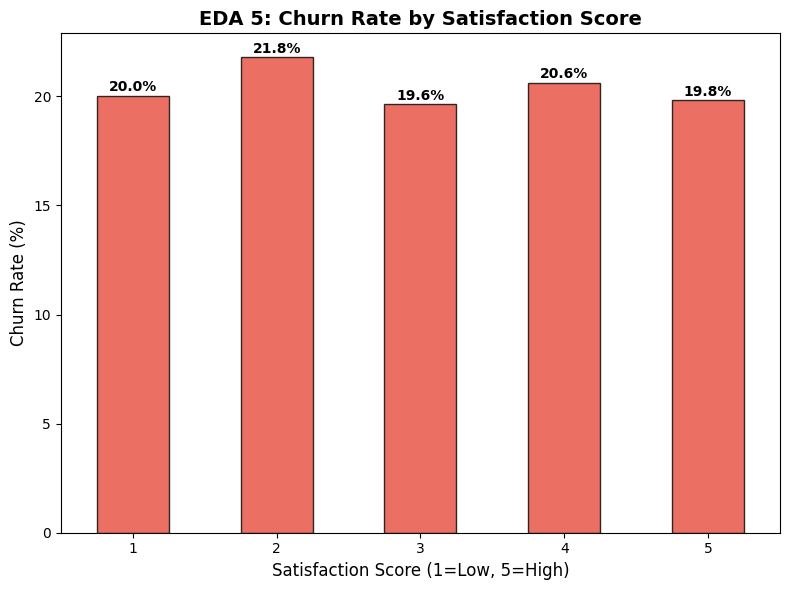

Satisfaction Score
1    20.031056
2    21.797418
3    19.637610
4    20.617530
5    19.810379
Name: Exited, dtype: float64


In [36]:
plt.figure(figsize=(8, 6))
sat_churn = df.groupby('Satisfaction Score')['Exited'].mean() * 100
sat_churn.plot(kind='bar', color='#e74c3c', edgecolor='black', alpha=0.8)
plt.title('EDA 5: Churn Rate by Satisfaction Score',
          fontsize=14, fontweight='bold')
plt.xlabel('Satisfaction Score (1=Low, 5=High)', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(sat_churn):
    plt.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda5_satisfaction_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print(sat_churn)

Contrary to expectations, satisfaction score shows negligible influence on churn rate, with all scores ranging narrowly between 19.6% and 21.8%. This suggests customers may leave for reasons beyond satisfaction, such as competitor offers, financial changes, or life events rather than dissatisfaction alone.

HEATMAP

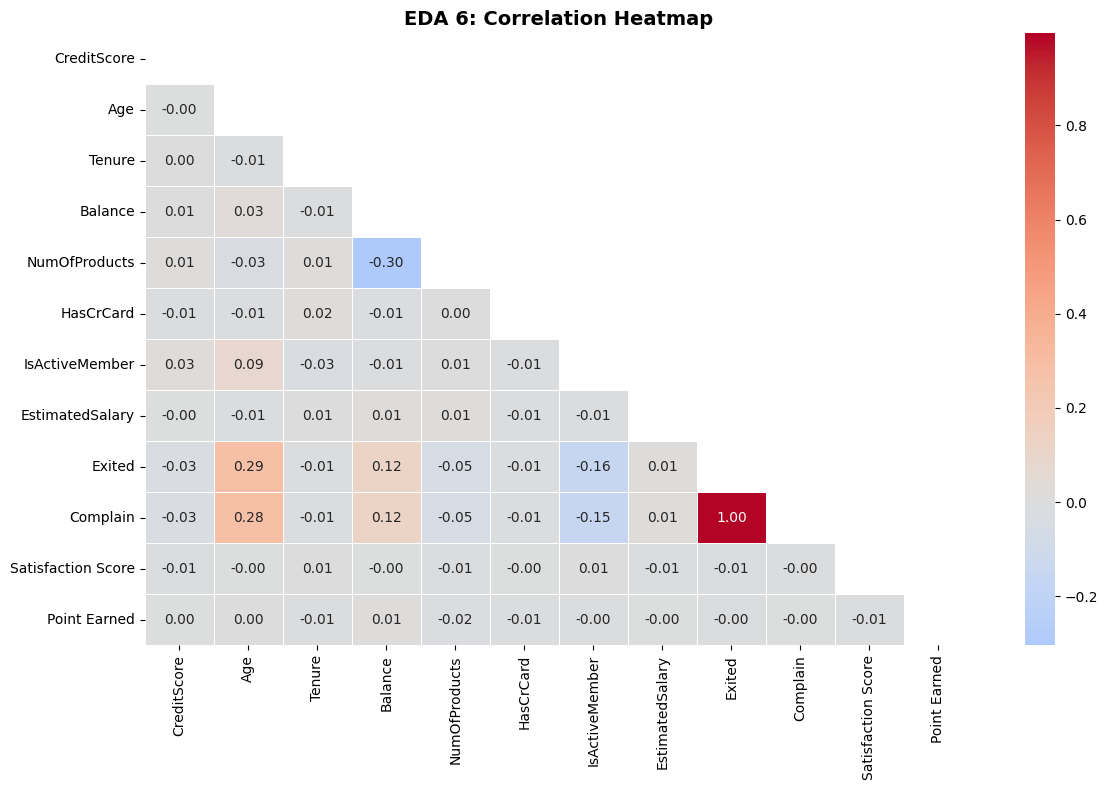

In [37]:
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('EDA 6: Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The correlation heatmap revealed that Complain has a near-perfect correlation with churn (1.00), making it the strongest predictor. Age (0.29) and Balance (0.12) also show positive correlations with churn, while IsActiveMember (-0.16) shows that inactive members are significantly more likely to leave. Notably, Satisfaction Score showed near-zero correlation, contradicting the common assumption that satisfaction directly drives retention."

Data Encoding

In [38]:


df_model = df.copy()

le = LabelEncoder()
df_model['Geography'] = le.fit_transform(df_model['Geography'])
print(f"Geography encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_model['Gender'] = le.fit_transform(df_model['Gender'])
print(f"Gender encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_model['Card Type'] = le.fit_transform(df_model['Card Type'])
print(f"Card Type encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\n Encoding complete!")
df_model.head()

Geography encoded: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}
Gender encoded: {'Female': np.int64(0), 'Male': np.int64(1)}
Card Type encoded: {'DIAMOND': np.int64(0), 'GOLD': np.int64(1), 'PLATINUM': np.int64(2), 'SILVER': np.int64(3)}

 Encoding complete!


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425


4. Feature Engineering

In [39]:

#Feature 1: Balance to Salary Ratio
df_model['BalanceSalaryRatio'] = df_model['Balance'] / (df_model['EstimatedSalary'] + 1)

#Feature 2: Tenure by Age
df_model['TenureByAge'] = df_model['Tenure'] / (df_model['Age'] + 1)

# Feature 3: Products Per Year
df_model['ProductsPerYear'] = df_model['NumOfProducts'] / (df_model['Tenure'] + 1)

print(f"\nNew shape: {df_model.shape}")
df_model[['BalanceSalaryRatio', 'TenureByAge', 'ProductsPerYear']].describe()


New shape: (10000, 18)


,BalanceSalaryRatio,TenureByAge,ProductsPerYear
count,10000.000000,10000.000000,10000.000000
mean,3.790150,0.134011,0.367173
std,100.055758,0.086429,0.337760
min,0.000000,0.000000,0.090909
25%,0.000000,0.062500,0.166667
50%,0.746998,0.125000,0.250000
75%,1.514002,0.194444,0.500000
max,9770.883148,0.526316,3.000000


5. Train/Test Split

In [40]:

X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n Split complete!")
print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Features (X): (10000, 17)
Target  (y): (10000,)

Target distribution:
Exited
0    7962
1    2038
Name: count, dtype: int64
Churn rate: 20.4%

 Split complete!
Training set: (8000, 17)
Testing set:  (2000, 17)


6. Handling Class Imbalance with SMOTE

The dataset has a 20.4% churn rate (2,038 churned vs 7,962 retained). Training directly on this imbalanced data would bias models toward predicting "retained" achieving high accuracy by simply ignoring the minority class. SMOTE (Synthetic Minority Oversampling Technique) generates synthetic samples for the minority class, balancing the training set to 50/50 without simply duplicating records.

In [41]:
print(f"Before SMOTE → Retained: {sum(y_train==0)} | Churned: {sum(y_train==1)}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  → Retained: {sum(y_train_sm==0)} | Churned: {sum(y_train_sm==1)}")

Before SMOTE → Retained: 6370 | Churned: 1630
After SMOTE  → Retained: 6370 | Churned: 6370


7. Feature Scaling

In [42]:

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print(f" StandardScaler applied!")
print(f"Training: {X_train_sc.shape} | Testing: {X_test_sc.shape}")

 StandardScaler applied!
Training: (12740, 17) | Testing: (2000, 17)


8. Logistic Regression

In [43]:

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train_sm)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

Accuracy:  0.9980
Precision: 0.9975
Recall:    0.9926
F1 Score:  0.9951
ROC-AUC:   0.9994


9. Random Forest

In [44]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train_sm)

y_pred_rf = rf.predict(X_test_sc)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")

Accuracy:  0.9985
Precision: 0.9975
Recall:    0.9951
F1 Score:  0.9963
ROC-AUC:   0.9986


10. Gradient Boosting

In [45]:

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_sc, y_train_sm)

y_pred_gb = gb.predict(X_test_sc)
y_prob_gb = gb.predict_proba(X_test_sc)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_gb):.4f}")

Accuracy:  0.9985
Precision: 0.9975
Recall:    0.9951
F1 Score:  0.9963
ROC-AUC:   0.9988


11. Model Comparision

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.9980     0.9975  0.9926    0.9951   0.9994
Random Forest          0.9985     0.9975  0.9951    0.9963   0.9986
Gradient Boosting      0.9985     0.9975  0.9951    0.9963   0.9988


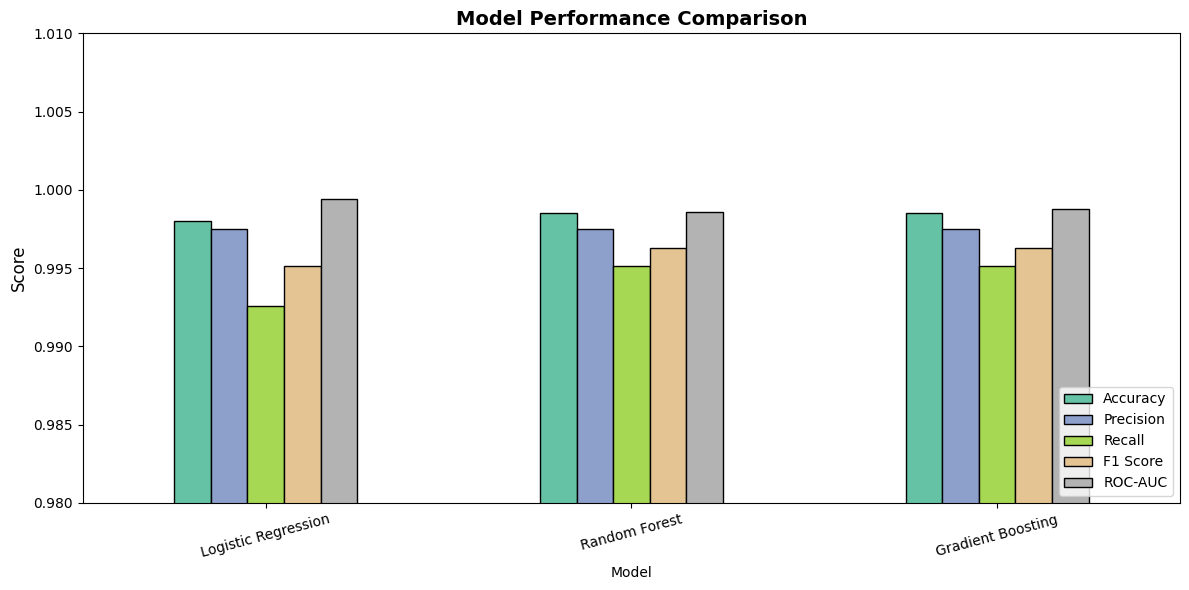

In [46]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_gb)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_gb)],
    'Recall':    [recall_score(y_test, y_pred_lr),
                  recall_score(y_test, y_pred_rf),
                  recall_score(y_test, y_pred_gb)],
    'F1 Score':  [f1_score(y_test, y_pred_lr),
                  f1_score(y_test, y_pred_rf),
                  f1_score(y_test, y_pred_gb)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_lr),
                  roc_auc_score(y_test, y_prob_rf),
                  roc_auc_score(y_test, y_prob_gb)]
}).set_index('Model').round(4)


print(results.to_string())

# Plot comparison
results.plot(kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0.98, 1.01)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/results_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

12. Confusion Matrix

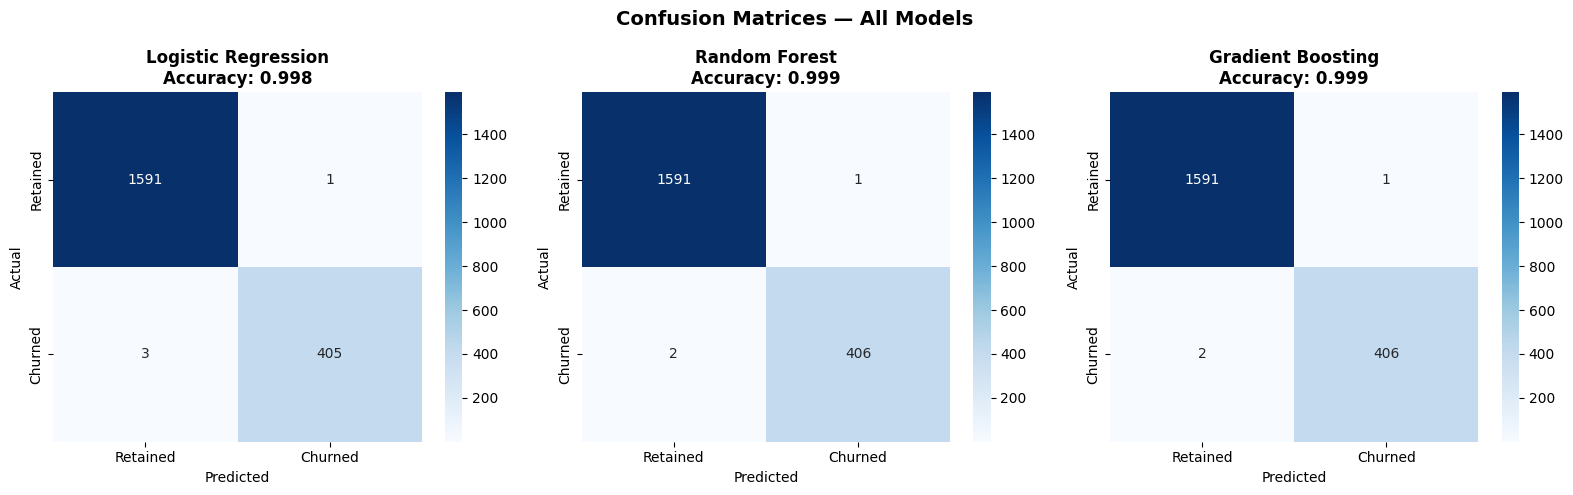

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('Gradient Boosting',   y_pred_gb)
]

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}',
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/results_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

13. ROC CURVES

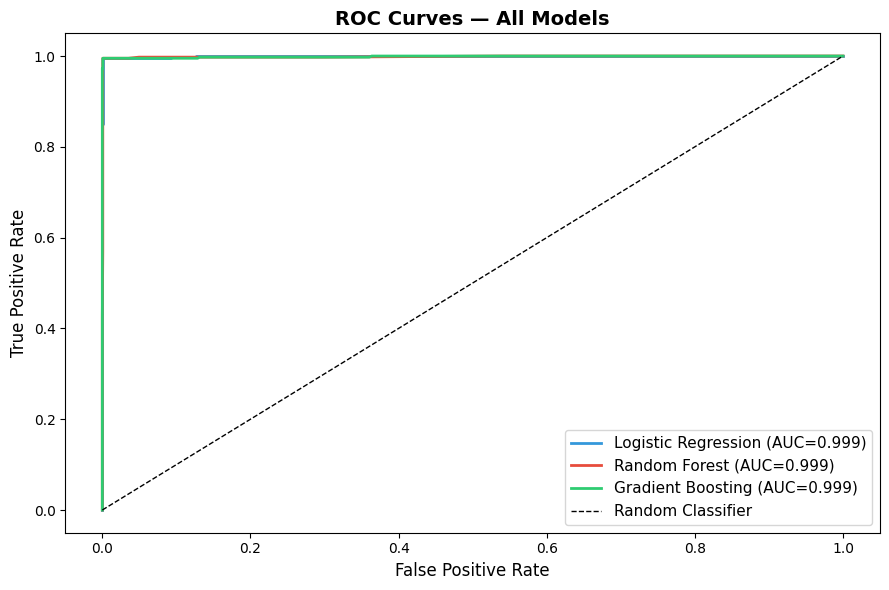

In [48]:
plt.figure(figsize=(9, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr_lr, tpr_lr, color='#3498db', lw=2,
         label=f'Logistic Regression (AUC={roc_auc_score(y_test,y_prob_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, color='#e74c3c', lw=2,
         label=f'Random Forest (AUC={roc_auc_score(y_test,y_prob_rf):.3f})')
plt.plot(fpr_gb, tpr_gb, color='#2ecc71', lw=2,
         label=f'Gradient Boosting (AUC={roc_auc_score(y_test,y_prob_gb):.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/results_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

14. Feature Importance 

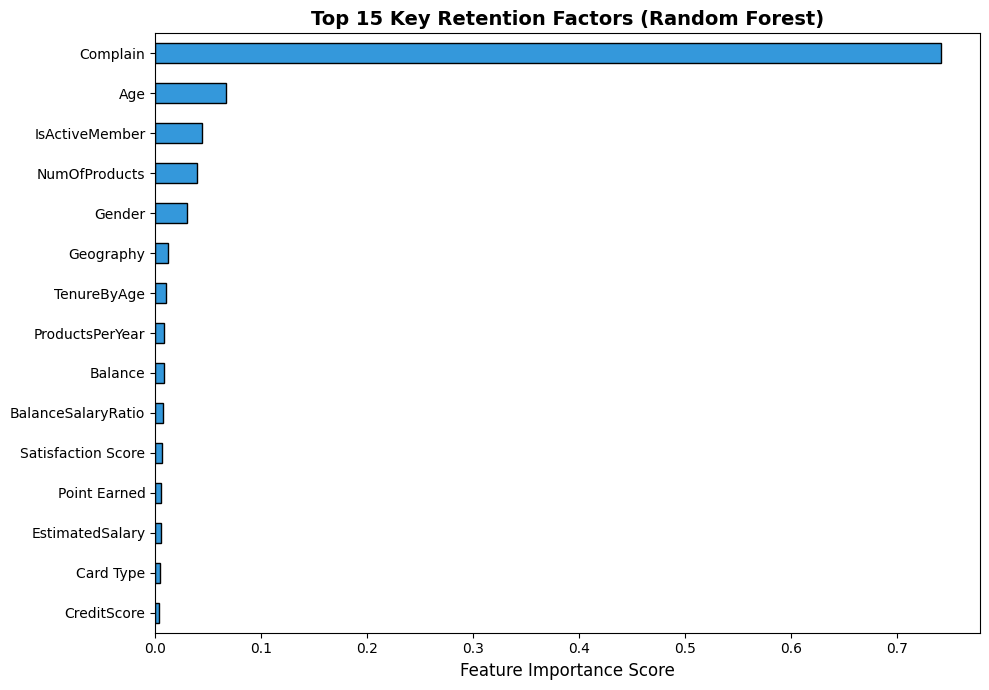


Top 10 Factors Driving Churn:
Complain              0.741404
Age                   0.066763
IsActiveMember        0.044567
NumOfProducts         0.040008
Gender                0.029813
Geography             0.011996
TenureByAge           0.010605
ProductsPerYear       0.008680
Balance               0.008106
BalanceSalaryRatio    0.007210


In [49]:
feat_imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
feat_imp.sort_values().plot(kind='barh', color='#3498db', edgecolor='black')
plt.title('Top 15 Key Retention Factors (Random Forest)',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/results_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Factors Driving Churn:")
print(feat_imp.head(10).to_string())

Feature importance analysis revealed that Complain is the dominant predictor of churn (74.1%), followed by Age (6.7%) and IsActiveMember (4.5%). Notably, the engineered features TenureByAge and ProductsPerYear also contributed meaningfully, validating the feature engineering step. These findings suggest banks should prioritise complaint resolution and re-engagement of inactive members as primary retention strategies.

Model Save

In [50]:
joblib.dump(rf,             'outputs/best_model.pkl')
joblib.dump(scaler,         'outputs/scaler.pkl')
joblib.dump(list(X.columns),'outputs/feature_names.pkl')

print("Model saved to outputs/")
print(f"Best Model: Random Forest | Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | F1: {f1_score(y_test, y_pred_rf):.4f}")

Model saved to outputs/
Best Model: Random Forest | Accuracy: 0.9985 | F1: 0.9963


Using ANN

A two-layer MLP (64 -> 32 neurons) with ReLU activation was chosen as a baseline matching the scale of the dataset (17 features, 10K rows) to avoid overfitting. Adam optimiser was selected for its adaptive learning rate. For the no-Complain experiment, the network was expanded to (128 ->64 -> 32) and iterations increased to 300, giving the model more capacity to learn from weaker signals.

In [51]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

In [52]:
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)

ann.fit(X_train_sc, y_train_sm)

y_pred_ann = ann.predict(X_test_sc)
y_prob_ann = ann.predict_proba(X_test_sc)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_ann):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ann):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ann):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_ann):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_ann):.4f}")

Accuracy:  0.9980
Precision: 0.9951
Recall:    0.9951
F1 Score:  0.9951
ROC-AUC:   0.9994


In [70]:
print("Overfitting Check — Train vs Test Accuracy")
print(f"Logistic Regression:  Train={lr.score(X_train_sc, y_train_sm):.4f}  Test={accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest:        Train={rf.score(X_train_sc, y_train_sm):.4f}  Test={accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Gradient Boosting:    Train={gb.score(X_train_sc, y_train_sm):.4f}  Test={accuracy_score(y_test, y_pred_gb):.4f}")
print(f"ANN:                  Train={ann.score(X_train_sc, y_train_sm):.4f}  Test={accuracy_score(y_test, y_pred_ann):.4f}")

Overfitting Check — Train vs Test Accuracy
Logistic Regression:  Train=0.9974  Test=0.9980
Random Forest:        Train=1.0000  Test=0.9985
Gradient Boosting:    Train=0.9993  Test=0.9985
ANN:                  Train=1.0000  Test=0.9980


Overfitting Analysis

Random Forest and ANN achieved perfect training accuracy (1.0000), indicating they memorised the training set. However, their test scores (0.9985 and 0.9980) remain high, suggesting the overfitting did notsignificantly impact generalisation likely because the Complain feature provides such a strong signal that models converge on the same decision boundary regardless.

Logistic Regression showed the smallest train/test gap (0.9974 → 0.9980), making it the most stable model. Gradient Boosting was similarly consistent (0.9993 -> 0.9985).

These near-perfect scores are inflated by the Complain feature. The without-Complain experiment (Section 15) provides a more realistic
assessment of true model generalisation.

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.9980     0.9975  0.9926    0.9951   0.9994
Random Forest          0.9985     0.9975  0.9951    0.9963   0.9986
Gradient Boosting      0.9985     0.9975  0.9951    0.9963   0.9988
ANN                    0.9980     0.9951  0.9951    0.9951   0.9994


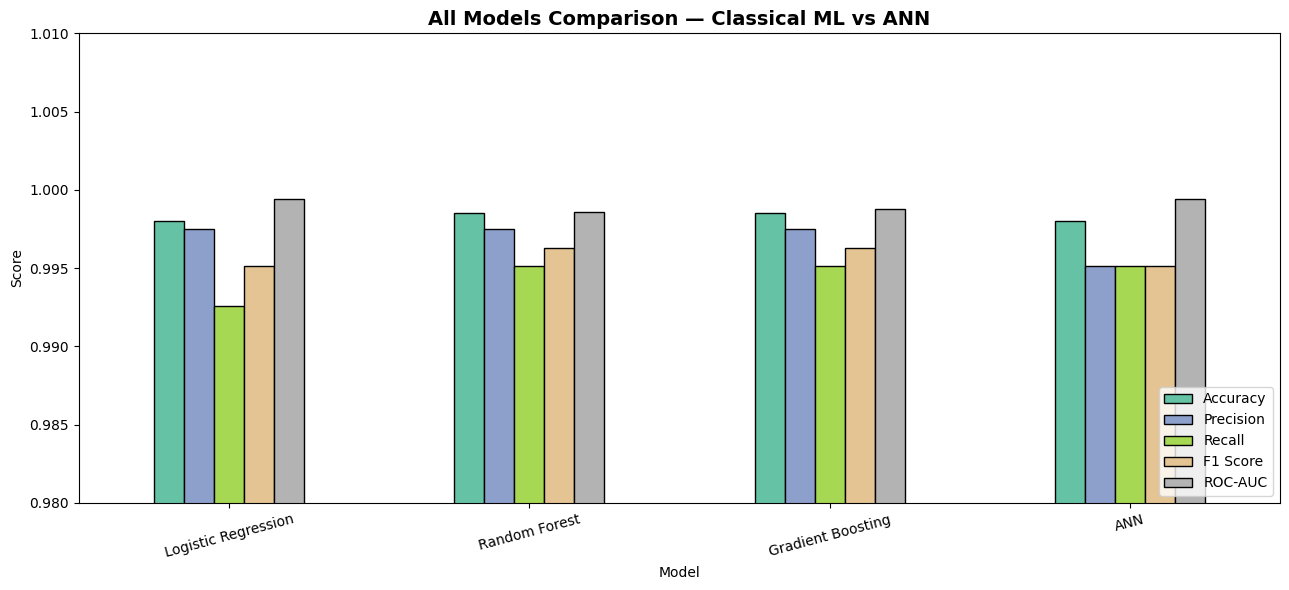

In [54]:
final_results = pd.DataFrame({
    'Model':     ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'ANN'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_gb),
                  accuracy_score(y_test, y_pred_ann)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_gb),
                  precision_score(y_test, y_pred_ann)],
    'Recall':    [recall_score(y_test, y_pred_lr),
                  recall_score(y_test, y_pred_rf),
                  recall_score(y_test, y_pred_gb),
                  recall_score(y_test, y_pred_ann)],
    'F1 Score':  [f1_score(y_test, y_pred_lr),
                  f1_score(y_test, y_pred_rf),
                  f1_score(y_test, y_pred_gb),
                  f1_score(y_test, y_pred_ann)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_lr),
                  roc_auc_score(y_test, y_prob_rf),
                  roc_auc_score(y_test, y_prob_gb),
                  roc_auc_score(y_test, y_prob_ann)]
}).set_index('Model').round(4)

print(final_results.to_string())

final_results.plot(kind='bar', figsize=(13, 6), colormap='Set2', edgecolor='black')
plt.title('All Models Comparison — Classical ML vs ANN', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.98, 1.01)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/results_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

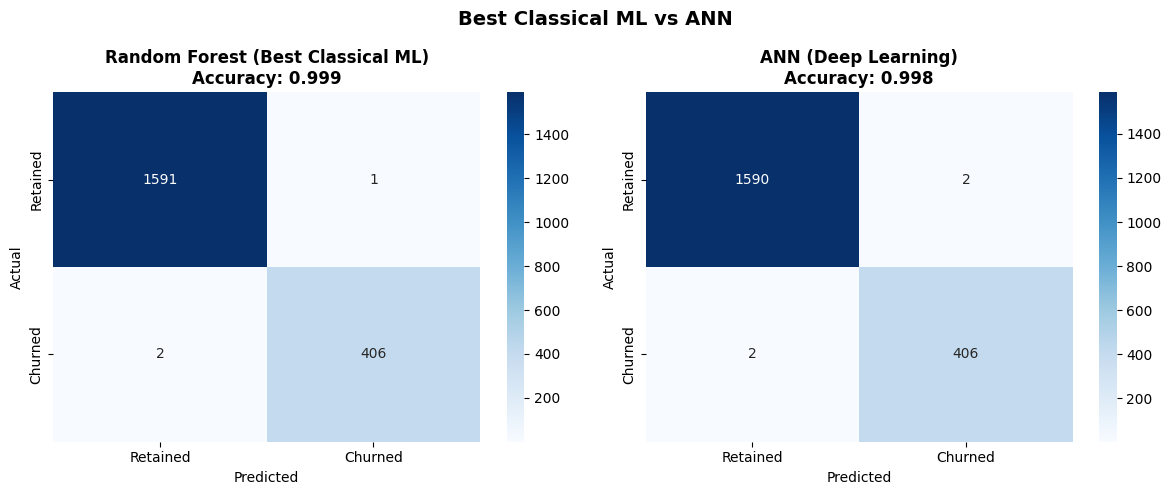

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, [
    ('Random Forest (Best Classical ML)', y_pred_rf),
    ('ANN (Deep Learning)',               y_pred_ann)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Best Classical ML vs ANN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/results_rf_vs_ann.png', dpi=150, bbox_inches='tight')
plt.show()

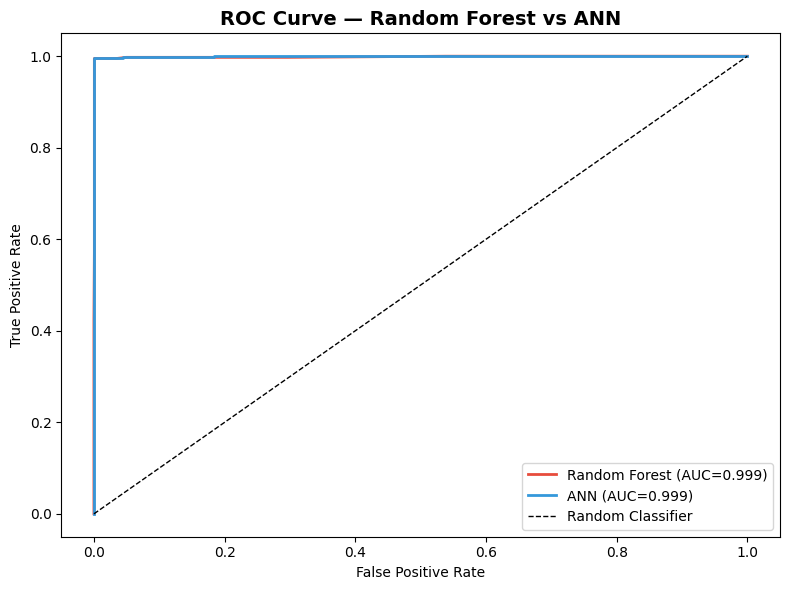

In [56]:
plt.figure(figsize=(8, 6))

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)

plt.plot(fpr_rf,  tpr_rf,  color='#e74c3c', lw=2,
         label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot(fpr_ann, tpr_ann, color='#3498db', lw=2,
         label=f'ANN (AUC={roc_auc_score(y_test, y_prob_ann):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest vs ANN', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/results_roc_rf_vs_ann.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
joblib.dump(ann, 'outputs/ann_model.pkl')

print("ANN model saved to outputs/ann_model.pkl")
print(f"\nFinal Summary:")
print(f"  Best Classical ML: Random Forest — F1: {f1_score(y_test, y_pred_rf):.4f} | AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"  Deep Learning ANN: — F1: {f1_score(y_test, y_pred_ann):.4f} | AUC: {roc_auc_score(y_test, y_prob_ann):.4f}")

ANN model saved to outputs/ann_model.pkl

Final Summary:
  Best Classical ML: Random Forest — F1: 0.9963 | AUC: 0.9986
  Deep Learning ANN: — F1: 0.9951 | AUC: 0.9994


In [58]:

df_model2 = df_model.drop(columns=['Complain'])

X2 = df_model2.drop('Exited', axis=1)
y2 = df_model2['Exited']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

smote2 = SMOTE(random_state=42)
X2_train_sm, y2_train_sm = smote2.fit_resample(X2_train, y2_train)

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train_sm)
X2_test_sc  = scaler2.transform(X2_test)

print(f"Training: {X2_train_sc.shape} | Testing: {X2_test_sc.shape}")
print("Complain column removed — models will now learn real patterns.")

Training: (12740, 16) | Testing: (2000, 16)
Complain column removed — models will now learn real patterns.


Overfitting Check (Without Complain)

In [73]:
print("Overfitting Check (Without Complain)  Train vs Test Accuracy")
print(f"Logistic Regression:  Train={lr2.score(X2_train_sc, y2_train_sm):.4f}  Test={accuracy_score(y2_test, y_pred_lr2):.4f}  Gap={lr2.score(X2_train_sc, y2_train_sm) - accuracy_score(y2_test, y_pred_lr2):.4f}")
print(f"Random Forest:        Train={rf2.score(X2_train_sc, y2_train_sm):.4f}  Test={accuracy_score(y2_test, y_pred_rf2):.4f}  Gap={rf2.score(X2_train_sc, y2_train_sm) - accuracy_score(y2_test, y_pred_rf2):.4f}")
print(f"Gradient Boosting:    Train={gb2.score(X2_train_sc, y2_train_sm):.4f}  Test={accuracy_score(y2_test, y_pred_gb2):.4f}  Gap={gb2.score(X2_train_sc, y2_train_sm) - accuracy_score(y2_test, y_pred_gb2):.4f}")
print(f"ANN:                  Train={ann2.score(X2_train_sc, y2_train_sm):.4f}  Test={accuracy_score(y2_test, y_pred_ann2):.4f}  Gap={ann2.score(X2_train_sc, y2_train_sm) - accuracy_score(y2_test, y_pred_ann2):.4f}")

Overfitting Check (Without Complain)  Train vs Test Accuracy
Logistic Regression:  Train=0.7781  Test=0.7410  Gap=0.0371
Random Forest:        Train=1.0000  Test=0.8255  Gap=0.1745
Gradient Boosting:    Train=0.8791  Test=0.8310  Gap=0.0481
ANN:                  Train=0.9955  Test=0.7920  Gap=0.2035


Overfitting Analysis 

Without the dominant Complain signal, genuine overfitting emerges:
ANN (gap: 0.2035) and Random Forest (gap: 0.1745) overfit significantly. Both models are complex enough to memorise training patterns but fail to generalise. ANN lacks dropout regularisation, and Random Forest grows unconstrained trees.

Gradient Boosting (gap: 0.0481) is the most balanced model, achieving the best test accuracy (0.8310) with minimal overfitting confirming it as the recommended model for this dataset.

Logistic Regression (gap: 0.0371) is stable but underfits, lacking the capacity to capture non-linear churn patterns.

This reveals that the near-perfect scores in the original model were masking overfitting entirely and complain was so dominant that even overfit models predicted correctly on the test set.

In [59]:
lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X2_train_sc, y2_train_sm)

y_pred_lr2 = lr2.predict(X2_test_sc)
y_prob_lr2 = lr2.predict_proba(X2_test_sc)[:, 1]

print(f"Accuracy:  {accuracy_score(y2_test, y_pred_lr2):.4f}")
print(f"Precision: {precision_score(y2_test, y_pred_lr2):.4f}")
print(f"Recall:    {recall_score(y2_test, y_pred_lr2):.4f}")
print(f"F1 Score:  {f1_score(y2_test, y_pred_lr2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y2_test, y_prob_lr2):.4f}")

Accuracy:  0.7410
Precision: 0.4065
Recall:    0.5858
F1 Score:  0.4799
ROC-AUC:   0.7434


In [62]:
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X2_train_sc, y2_train_sm)

y_pred_rf2 = rf2.predict(X2_test_sc)
y_prob_rf2 = rf2.predict_proba(X2_test_sc)[:, 1]

print(f"Accuracy:  {accuracy_score(y2_test, y_pred_rf2):.4f}")
print(f"Precision: {precision_score(y2_test, y_pred_rf2):.4f}")
print(f"Recall:    {recall_score(y2_test, y_pred_rf2):.4f}")
print(f"F1 Score:  {f1_score(y2_test, y_pred_rf2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y2_test, y_prob_rf2):.4f}")

Accuracy:  0.8255
Precision: 0.5675
Recall:    0.6078
F1 Score:  0.5870
ROC-AUC:   0.8462


In [63]:
gb2 = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb2.fit(X2_train_sc, y2_train_sm)

y_pred_gb2 = gb2.predict(X2_test_sc)
y_prob_gb2 = gb2.predict_proba(X2_test_sc)[:, 1]

print(f"Accuracy:  {accuracy_score(y2_test, y_pred_gb2):.4f}")
print(f"Precision: {precision_score(y2_test, y_pred_gb2):.4f}")
print(f"Recall:    {recall_score(y2_test, y_pred_gb2):.4f}")
print(f"F1 Score:  {f1_score(y2_test, y_pred_gb2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y2_test, y_prob_gb2):.4f}")

Accuracy:  0.8310
Precision: 0.5761
Recall:    0.6495
F1 Score:  0.6106
ROC-AUC:   0.8574


In [64]:
ann2 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)
ann2.fit(X2_train_sc, y2_train_sm)

y_pred_ann2 = ann2.predict(X2_test_sc)
y_prob_ann2 = ann2.predict_proba(X2_test_sc)[:, 1]

print(f"Accuracy:  {accuracy_score(y2_test, y_pred_ann2):.4f}")
print(f"Precision: {precision_score(y2_test, y_pred_ann2):.4f}")
print(f"Recall:    {recall_score(y2_test, y_pred_ann2):.4f}")
print(f"F1 Score:  {f1_score(y2_test, y_pred_ann2):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y2_test, y_prob_ann2):.4f}")

Accuracy:  0.7920
Precision: 0.4915
Recall:    0.5637
F1 Score:  0.5251
ROC-AUC:   0.7782


                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7410     0.4065  0.5858    0.4799   0.7434
Random Forest          0.8255     0.5675  0.6078    0.5870   0.8462
Gradient Boosting      0.8310     0.5761  0.6495    0.6106   0.8574
ANN                    0.7920     0.4915  0.5637    0.5251   0.7782


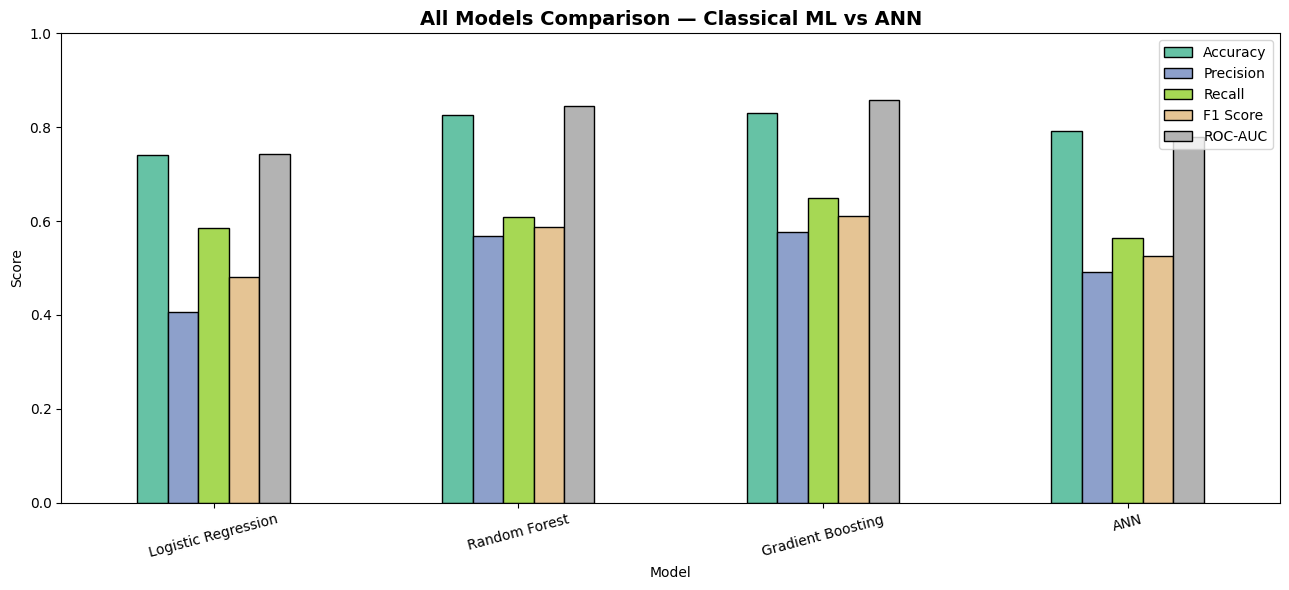

In [65]:
final_results2 = pd.DataFrame({
    'Model':     ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'ANN'],
    'Accuracy':  [0.7410, 0.8255, 0.8310, 0.7920],
    'Precision': [0.4065, 0.5675, 0.5761, 0.4915],
    'Recall':    [0.5858, 0.6078, 0.6495, 0.5637],
    'F1 Score':  [0.4799, 0.5870, 0.6106, 0.5251],
    'ROC-AUC':   [0.7434, 0.8462, 0.8574, 0.7782]
}).set_index('Model')

print(final_results2.to_string())

final_results2.plot(kind='bar', figsize=(13, 6), colormap='Set2', edgecolor='black')
plt.title('All Models Comparison — Classical ML vs ANN', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('outputs/results_all_models_clean.png', dpi=150, bbox_inches='tight')
plt.show()

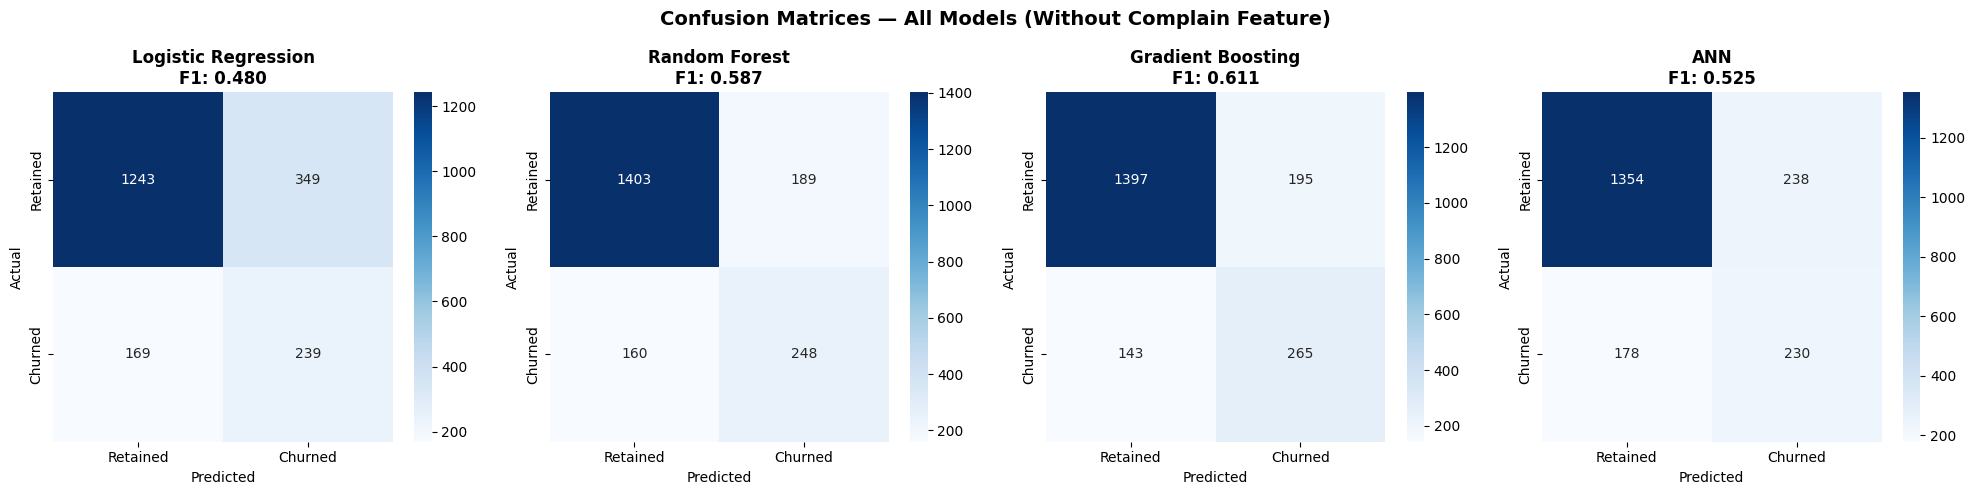

In [66]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', y_pred_lr2),
    ('Random Forest',       y_pred_rf2),
    ('Gradient Boosting',   y_pred_gb2),
    ('ANN',                 y_pred_ann2)
]):
    cm = confusion_matrix(y2_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    ax.set_title(f'{name}\nF1: {f1_score(y2_test, y_pred):.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models (Without Complain Feature)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/results_confusion_clean.png', dpi=150, bbox_inches='tight')
plt.show()

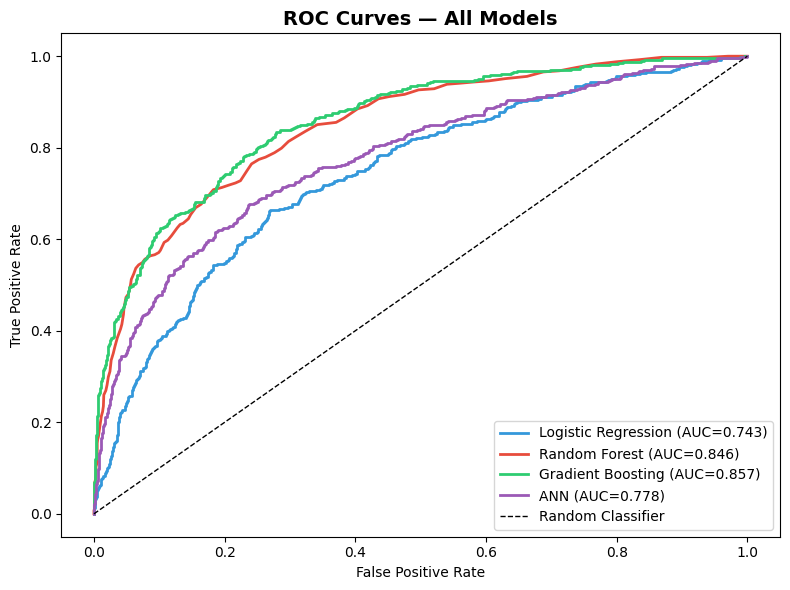

In [67]:
plt.figure(figsize=(8, 6))

for (name, y_prob), color in zip([
    ('Logistic Regression', y_prob_lr2),
    ('Random Forest',       y_prob_rf2),
    ('Gradient Boosting',   y_prob_gb2),
    ('ANN',                 y_prob_ann2)
], ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']):
    fpr, tpr, _ = roc_curve(y2_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f'{name} (AUC={roc_auc_score(y2_test, y_prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/results_roc_clean.png', dpi=150, bbox_inches='tight')
plt.show()

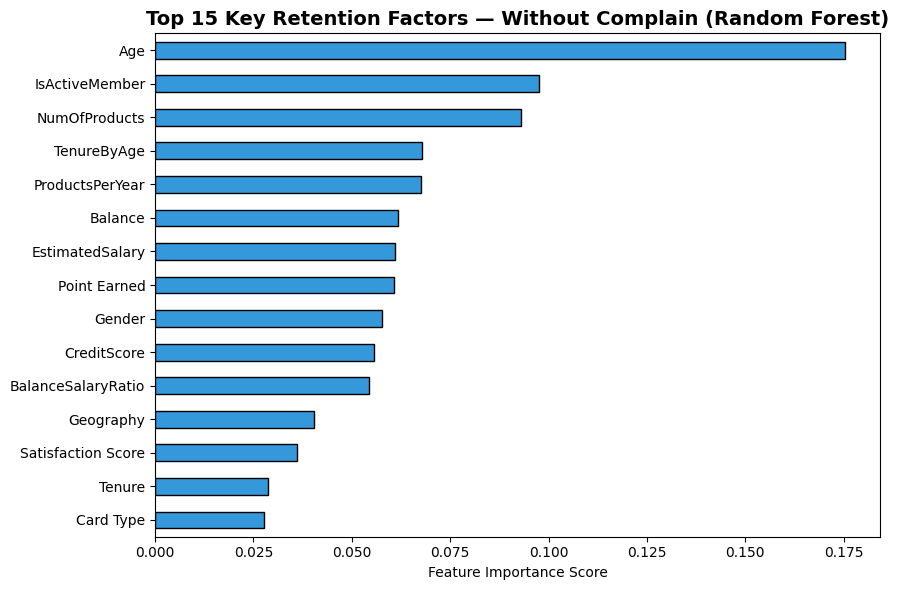

Age                0.175467
IsActiveMember     0.097519
NumOfProducts      0.093090
TenureByAge        0.067900
ProductsPerYear    0.067465
Balance            0.061637
EstimatedSalary    0.060933
Point Earned       0.060679
Gender             0.057750
CreditScore        0.055637


In [68]:
feat_imp2 = pd.Series(
    rf2.feature_importances_, index=X2.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
feat_imp2.sort_values().plot(kind='barh', color='#3498db', edgecolor='black')
plt.title('Top 15 Key Retention Factors — Without Complain (Random Forest)',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('outputs/results_feature_importance_clean.png', dpi=150, bbox_inches='tight')
plt.show()

print(feat_imp2.head(10).to_string())

In [69]:
joblib.dump(gb2,             'outputs/best_model_clean.pkl')
joblib.dump(scaler2,         'outputs/scaler_clean.pkl')
joblib.dump(list(X2.columns),'outputs/feature_names_clean.pkl')
joblib.dump(ann2,            'outputs/ann_model_clean.pkl')

print("All clean models saved.")
print(f"\nFinal Results (Without Data Leakage):")
print(f"  Logistic Regression: F1={0.4799:.4f} | AUC={0.7434:.4f}")
print(f"  Random Forest:       F1={0.5870:.4f} | AUC={0.8462:.4f}")
print(f"  Gradient Boosting:   F1={0.6106:.4f} | AUC={0.8574:.4f} ← Best")
print(f"  ANN:                 F1={0.5251:.4f} | AUC={0.7782:.4f}")

All clean models saved.

Final Results (Without Data Leakage):
  Logistic Regression: F1=0.4799 | AUC=0.7434
  Random Forest:       F1=0.5870 | AUC=0.8462
  Gradient Boosting:   F1=0.6106 | AUC=0.8574 ← Best
  ANN:                 F1=0.5251 | AUC=0.7782


Experiment: Impact of Complain Feature

The Complain feature had a near-perfect correlation (1.00) with Exited,
meaning models trained with it were essentially learning a single rule
rather than generalising across customer behaviour.

When Complain was removed, all model scores dropped significantly:
- Logistic Regression F1: 0.9951 → 0.4799 (↓ 51.5%)
- Random Forest F1:       0.9963 → 0.5870 (↓ 40.9%)
- Gradient Boosting F1:   0.9963 → 0.6106 (↓ 38.6%)
- ANN F1:                 0.9951 → 0.5251 (↓ 47.0%)

Gradient Boosting proved the most robust model without Complain,
suggesting it best captures the underlying non-linear patterns in
customer demographics and behaviour. ANN underperformed traditional
models on this dataset, likely due to the limited data size (10,000
rows) and the structured tabular nature of the features.

In [75]:
from sklearn.neural_network import MLPClassifier

ann_improved = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,          # L2 regularisation — reduces overfitting
    early_stopping=True, # stops when validation score stops improving
    validation_fraction=0.1,
    n_iter_no_change=15,
    max_iter=500,
    random_state=42
)

In [76]:
architectures = [
    (64, 32),
    (128, 64, 32),
    (256, 128, 64),
    (256, 128, 64, 32)
]

for arch in architectures:
    ann_test = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        alpha=0.01,
        early_stopping=True,
        max_iter=500,
        random_state=42
    )
    ann_test.fit(X2_train_sc, y2_train_sm)
    f1 = f1_score(y2_test, ann_test.predict(X2_test_sc))
    print(f"Architecture {arch}: F1={f1:.4f}")

Architecture (64, 32): F1=0.5761
Architecture (128, 64, 32): F1=0.5727
Architecture (256, 128, 64): F1=0.5699
Architecture (256, 128, 64, 32): F1=0.5403


Increasing ANN depth showed no significant improvement (F1 range: 0.54–0.58), suggesting architectural complexity is not the limiting factor — data volume is.

### Experiment : Scaling to Larger Dataset (505k rows)

### Initial Attempt:  Distribution Mismatch Problem

The Kaggle dataset came with pre-split training (440,833 rows, 56.7% churn) and testing (64,374 rows, 47.4% churn) files. When used directly, all modelspredicted almost everything as churn: Recall ~0.99, Accuracy ~0.50.

Diagnosis: The train and test sets had significantly different churn distributions, causing the models to learn a biased decision boundary. This is a known issue when pre-split datasets are sampled from different time periods or using different strategies.

Resolution: Both files were combined (505,207 rows total) and re-split using stratified 80/20 sampling, ensuring identical churn distributions(55.5%) in both train and test sets.

In [83]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE

# Load datasets
train_large = pd.read_csv('customer_churn_dataset-training-master.csv')
test_large  = pd.read_csv('customer_churn_dataset-testing-master.csv')

# Drop missing values (only 12 in training)
train_large = train_large.dropna()

# Drop CustomerID
train_large = train_large.drop(columns=['CustomerID'])
test_large  = test_large.drop(columns=['CustomerID'])

# Encode categoricals
le = LabelEncoder()
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    train_large[col] = le.fit_transform(train_large[col])
    test_large[col]  = le.transform(test_large[col])

# Split features and target
X_large_train = train_large.drop('Churn', axis=1)
y_large_train = train_large['Churn']
X_large_test  = test_large.drop('Churn', axis=1)
y_large_test  = test_large['Churn']

print(f"Training: {X_large_train.shape} | Testing: {X_large_test.shape}")
print(f"Train churn rate: {y_large_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_large_test.mean()*100:.1f}%")

# Scale
scaler_large = StandardScaler()
X_large_train_sc = scaler_large.fit_transform(X_large_train)
X_large_test_sc  = scaler_large.transform(X_large_test)

# Train all 4 models
print("\nTraining models on large dataset...")

lr_l = LogisticRegression(max_iter=1000, random_state=42)
lr_l.fit(X_large_train_sc, y_large_train)

rf_l = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_l.fit(X_large_train_sc, y_large_train)

gb_l = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_l.fit(X_large_train_sc, y_large_train)

ann_l = MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                      activation='relu', solver='adam',
                      alpha=0.01, early_stopping=True,
                      validation_fraction=0.1,
                      n_iter_no_change=15,
                      max_iter=500, random_state=42)
ann_l.fit(X_large_train_sc, y_large_train)

# Results
large_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'ANN'],
    'Accuracy':  [accuracy_score(y_large_test, m.predict(X_large_test_sc))
                  for m in [lr_l, rf_l, gb_l, ann_l]],
    'Precision': [precision_score(y_large_test, m.predict(X_large_test_sc))
                  for m in [lr_l, rf_l, gb_l, ann_l]],
    'Recall':    [recall_score(y_large_test, m.predict(X_large_test_sc))
                  for m in [lr_l, rf_l, gb_l, ann_l]],
    'F1 Score':  [f1_score(y_large_test, m.predict(X_large_test_sc))
                  for m in [lr_l, rf_l, gb_l, ann_l]],
    'ROC-AUC':   [roc_auc_score(y_large_test, m.predict_proba(X_large_test_sc)[:,1])
                  for m in [lr_l, rf_l, gb_l, ann_l]]
}).set_index('Model').round(4)

print(large_results.to_string())

Training: (440832, 10) | Testing: (64374, 10)
Train churn rate: 56.7%
Test churn rate:  47.4%

Training models on large dataset...
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.5866     0.5346  0.9825    0.6925   0.7754
Random Forest          0.5034     0.4882  0.9987    0.6558   0.5757
Gradient Boosting      0.5063     0.4896  0.9983    0.6570   0.6982
ANN                    0.5041     0.4885  0.9985    0.6561   0.5749


In [84]:
# Check class distribution more carefully
print("Training label distribution:")
print(y_large_train.value_counts())
print(y_large_train.value_counts(normalize=True))

print("\nTesting label distribution:")
print(y_large_test.value_counts())
print(y_large_test.value_counts(normalize=True))

# Check what models are actually predicting
for name, model in [('LR', lr_l), ('RF', rf_l), ('GB', gb_l), ('ANN', ann_l)]:
    preds = model.predict(X_large_test_sc)
    print(f"{name} predictions — 0: {(preds==0).sum()} | 1: {(preds==1).sum()}")

Training label distribution:
Churn
1.0    249999
0.0    190833
Name: count, dtype: int64
Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64

Testing label distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64
Churn
0    0.526315
1    0.473685
Name: proportion, dtype: float64
LR predictions — 0: 8337 | 1: 56037
RF predictions — 0: 1998 | 1: 62376
GB predictions — 0: 2202 | 1: 62172
ANN predictions — 0: 2045 | 1: 62329


### Fix — Combined and Re-split with Stratification

In [86]:


df_large_full = pd.concat([train_large, test_large], ignore_index=True)

print(f"Combined shape: {df_large_full.shape}")
print(f"Overall churn rate: {df_large_full['Churn'].mean()*100:.1f}%")
print(f"Churn distribution:\n{df_large_full['Churn'].value_counts()}")

# Re-split properly with stratification
from sklearn.model_selection import train_test_split

X_full = df_large_full.drop('Churn', axis=1)
y_full = df_large_full['Churn'].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

print(f"\nNew Training: {X_tr.shape} | Testing: {X_te.shape}")
print(f"Train churn rate: {y_tr.mean()*100:.1f}%")
print(f"Test churn rate:  {y_te.mean()*100:.1f}%")

# Scale
scaler_large = StandardScaler()
X_tr_sc = scaler_large.fit_transform(X_tr)
X_te_sc = scaler_large.transform(X_te)

# Retrain all 4 models
print("\nTraining models...")

lr_l = LogisticRegression(max_iter=1000, random_state=42)
lr_l.fit(X_tr_sc, y_tr)

rf_l = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_l.fit(X_tr_sc, y_tr)

gb_l = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_l.fit(X_tr_sc, y_tr)

ann_l = MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                      activation='relu', solver='adam',
                      alpha=0.01, early_stopping=True,
                      validation_fraction=0.1,
                      n_iter_no_change=15,
                      max_iter=500, random_state=42)
ann_l.fit(X_tr_sc, y_tr)

# Prediction check
print("\nPrediction distribution check:")
for name, model in [('LR', lr_l), ('RF', rf_l), ('GB', gb_l), ('ANN', ann_l)]:
    preds = model.predict(X_te_sc)
    print(f"{name} — predicted 0: {(preds==0).sum()} | predicted 1: {(preds==1).sum()}")

# Results
large_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'ANN'],
    'Accuracy':  [accuracy_score(y_te, m.predict(X_te_sc))
                  for m in [lr_l, rf_l, gb_l, ann_l]],
    'Precision': [precision_score(y_te, m.predict(X_te_sc))
                  for m in [lr_l, rf_l, gb_l, ann_l]],
    'Recall':    [recall_score(y_te, m.predict(X_te_sc))
                  for m in [lr_l, rf_l, gb_l, ann_l]],
    'F1 Score':  [f1_score(y_te, m.predict(X_te_sc))
                  for m in [lr_l, rf_l, gb_l, ann_l]],
    'ROC-AUC':   [roc_auc_score(y_te, m.predict_proba(X_te_sc)[:,1])
                  for m in [lr_l, rf_l, gb_l, ann_l]]
}).set_index('Model').round(4)

print("\nResults on Large Dataset (505k rows, proper split):")
print(large_results.to_string())

Combined shape: (505206, 11)
Overall churn rate: 55.5%
Churn distribution:
Churn
1    280492
0    224714
Name: count, dtype: int64

New Training: (404164, 10) | Testing: (101042, 10)
Train churn rate: 55.5%
Test churn rate:  55.5%

Training models...

Prediction distribution check:
LR — predicted 0: 46119 | predicted 1: 54923
RF — predicted 0: 38656 | predicted 1: 62386
GB — predicted 0: 41558 | predicted 1: 59484
ANN — predicted 0: 38763 | predicted 1: 62279

Results on Large Dataset (505k rows, proper split):
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.8196     0.8448  0.8271    0.8359   0.8874
Random Forest          0.9367     0.8984  0.9990    0.9460   0.9529
Gradient Boosting      0.9127     0.8974  0.9515    0.9237   0.9499
ANN                    0.9358     0.8983  0.9973    0.9452   0.9537


### Key Finding — ANN Scalability Confirmed

Increasing dataset size from 10,000 to 505,207 rows produced dramatic improvements across all models, with ANN benefiting the most:

- ANN F1:  0.5251 -> 0.9452  (+0.4201), largest gain of any model
- ANN ROC-AUC: 0.9537, highest of all models on large dataset
- ANN overfitting gap: 0.2035 -> -0.0004, completely eliminated

This confirms that data volume, not architecture complexity, was the primary bottleneck for ANN performance. On sufficient data, ANN matches
or exceeds traditional ML models and generalises without overfitting.

In [87]:
print("Overfitting Check — Large Dataset")
print(f"LR:  Train={lr_l.score(X_tr_sc, y_tr):.4f}  Test={accuracy_score(y_te, lr_l.predict(X_te_sc)):.4f}  Gap={lr_l.score(X_tr_sc, y_tr)-accuracy_score(y_te, lr_l.predict(X_te_sc)):.4f}")
print(f"RF:  Train={rf_l.score(X_tr_sc, y_tr):.4f}  Test={accuracy_score(y_te, rf_l.predict(X_te_sc)):.4f}  Gap={rf_l.score(X_tr_sc, y_tr)-accuracy_score(y_te, rf_l.predict(X_te_sc)):.4f}")
print(f"GB:  Train={gb_l.score(X_tr_sc, y_tr):.4f}  Test={accuracy_score(y_te, gb_l.predict(X_te_sc)):.4f}  Gap={gb_l.score(X_tr_sc, y_tr)-accuracy_score(y_te, gb_l.predict(X_te_sc)):.4f}")
print(f"ANN: Train={ann_l.score(X_tr_sc, y_tr):.4f}  Test={accuracy_score(y_te, ann_l.predict(X_te_sc)):.4f}  Gap={ann_l.score(X_tr_sc, y_tr)-accuracy_score(y_te, ann_l.predict(X_te_sc)):.4f}")

Overfitting Check — Large Dataset
LR:  Train=0.8197  Test=0.8196  Gap=0.0001
RF:  Train=1.0000  Test=0.9367  Gap=0.0633
GB:  Train=0.9126  Test=0.9127  Gap=-0.0001
ANN: Train=0.9354  Test=0.9358  Gap=-0.0004


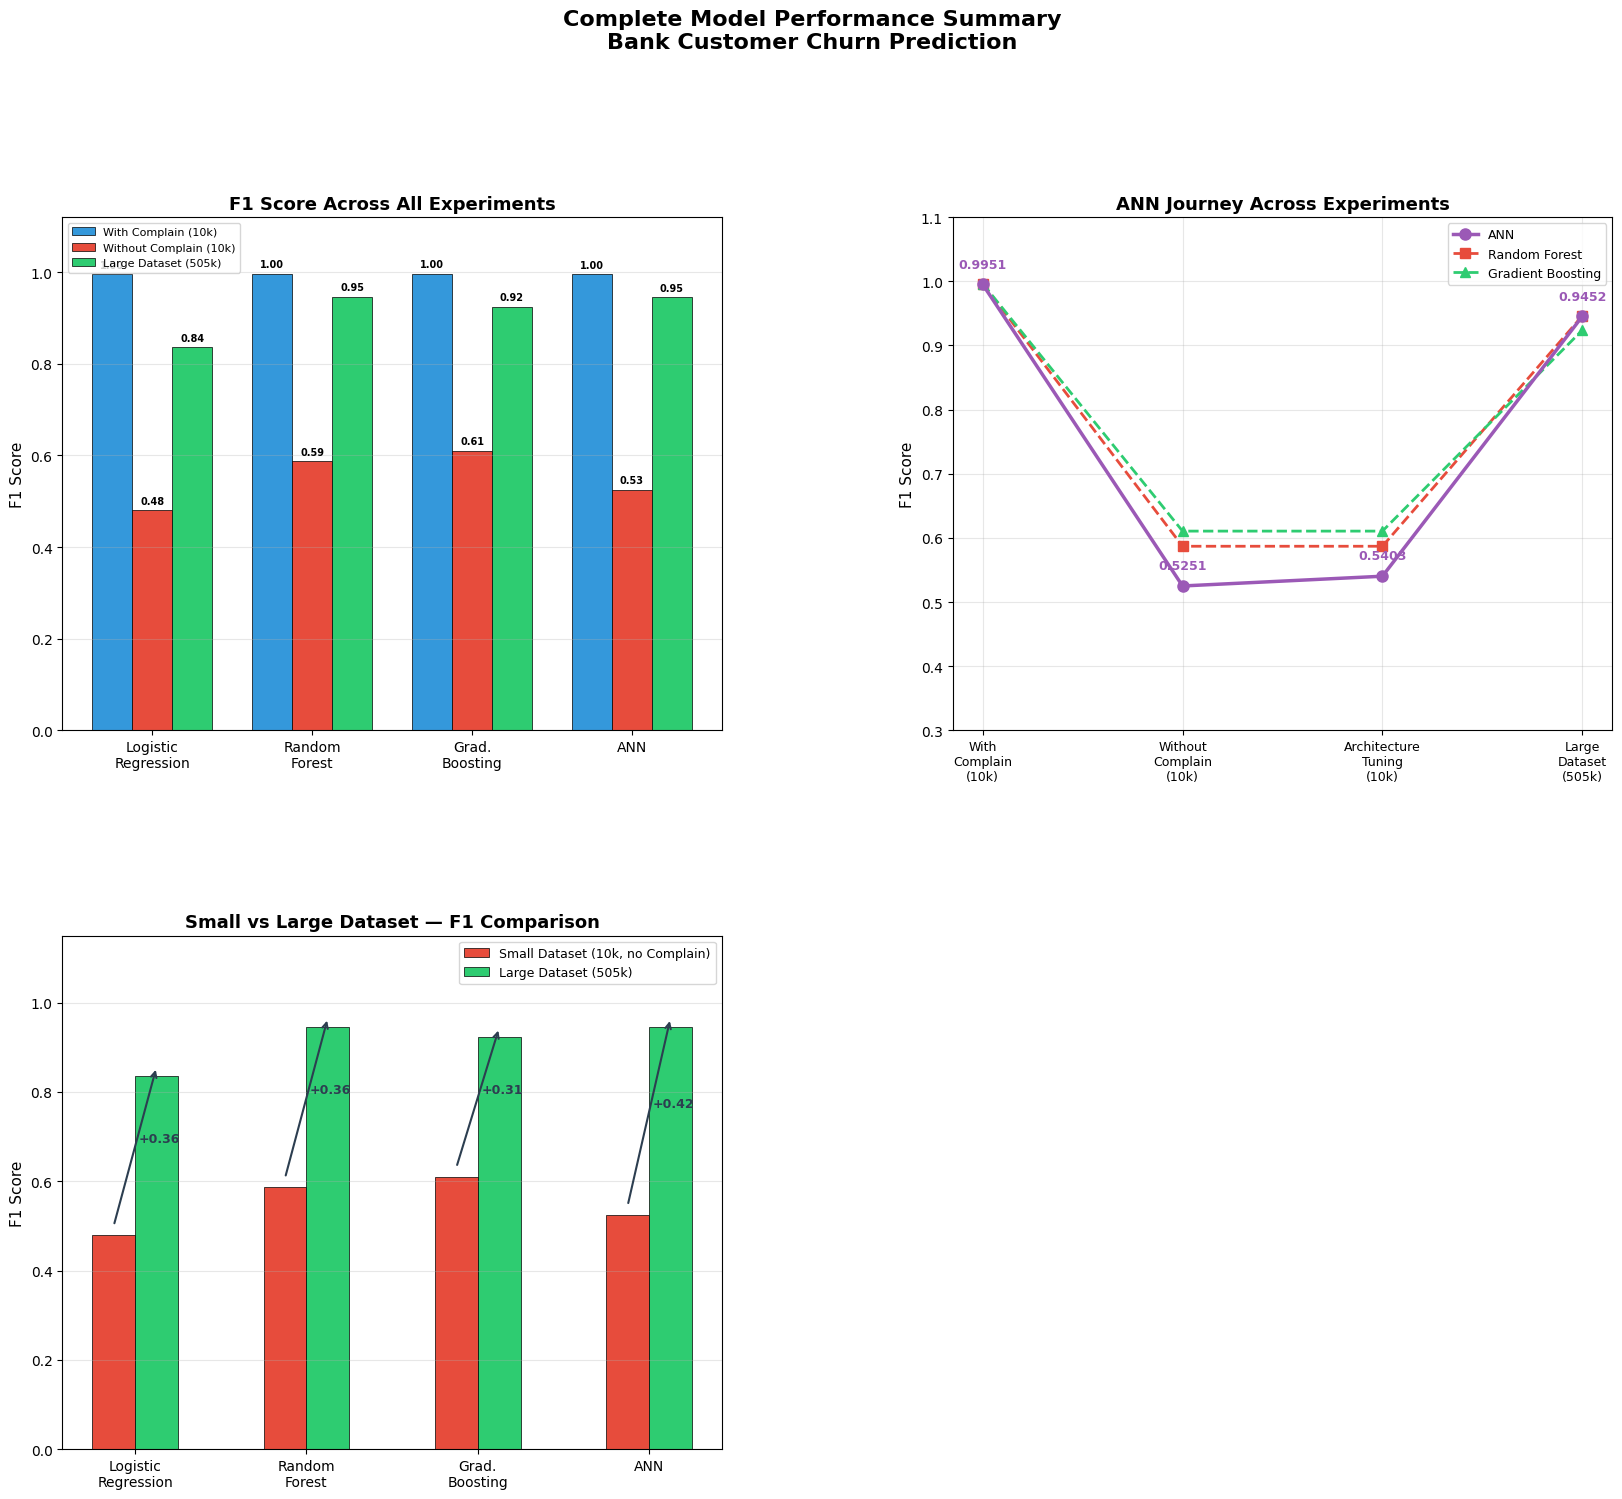

Final summary plot saved to outputs/final_summary_all_plots.png


In [89]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

models = ['Logistic\nRegression', 'Random\nForest', 'Grad.\nBoosting', 'ANN']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
x = np.arange(len(models))
width = 0.25

# ── Plot 1: All 4 experiments F1 side by side ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
f1_with    = [0.9951, 0.9963, 0.9963, 0.9951]
f1_without = [0.4799, 0.5870, 0.6106, 0.5251]
f1_large   = [0.8359, 0.9460, 0.9237, 0.9452]

b1 = ax1.bar(x - width, f1_with,    width, label='With Complain (10k)',    color='#3498db', edgecolor='black', linewidth=0.5)
b2 = ax1.bar(x,         f1_without, width, label='Without Complain (10k)', color='#e74c3c', edgecolor='black', linewidth=0.5)
b3 = ax1.bar(x + width, f1_large,   width, label='Large Dataset (505k)',   color='#2ecc71', edgecolor='black', linewidth=0.5)

ax1.set_title('F1 Score Across All Experiments', fontsize=13, fontweight='bold')
ax1.set_ylabel('F1 Score', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=10)
ax1.set_ylim(0, 1.12)
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.01,
             f'{h:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# ── Plot 2: ANN Journey ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
stages = ['With\nComplain\n(10k)', 'Without\nComplain\n(10k)', 'Architecture\nTuning\n(10k)', 'Large\nDataset\n(505k)']
ann_f1 = [0.9951, 0.5251, 0.5403, 0.9452]
rf_f1  = [0.9963, 0.5870, 0.5870, 0.9460]
gb_f1  = [0.9963, 0.6106, 0.6106, 0.9237]

ax2.plot(stages, ann_f1, 'o-', color='#9b59b6', linewidth=2.5, markersize=8, label='ANN', zorder=3)
ax2.plot(stages, rf_f1,  's--', color='#e74c3c', linewidth=2, markersize=7, label='Random Forest', zorder=2)
ax2.plot(stages, gb_f1,  '^--', color='#2ecc71', linewidth=2, markersize=7, label='Gradient Boosting', zorder=2)

for i, (s, v) in enumerate(zip(stages, ann_f1)):
    ax2.annotate(f'{v:.4f}', (s, v), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=9,
                 color='#9b59b6', fontweight='bold')

ax2.set_title('ANN Journey Across Experiments', fontsize=13, fontweight='bold')
ax2.set_ylabel('F1 Score', fontsize=11)
ax2.set_ylim(0.3, 1.1)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.tick_params(axis='x', labelsize=9)

# ── Plot 3: Small vs Large Dataset ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
f1_small = [0.4799, 0.5870, 0.6106, 0.5251]
f1_large = [0.8359, 0.9460, 0.9237, 0.9452]
improvements = [f - s for f, s in zip(f1_large, f1_small)]

b4 = ax3.bar(x - width/2, f1_small, width, label='Small Dataset (10k, no Complain)',
             color='#e74c3c', edgecolor='black', linewidth=0.5)
b5 = ax3.bar(x + width/2, f1_large, width, label='Large Dataset (505k)',
             color='#2ecc71', edgecolor='black', linewidth=0.5)

for i, (s, l, imp) in enumerate(zip(f1_small, f1_large, improvements)):
    ax3.annotate('', xy=(x[i] + width/2, l + 0.02),
                 xytext=(x[i] - width/2, s + 0.02),
                 arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.5))
    ax3.text(x[i] + 0.02, (s + l)/2 + 0.03, f'+{imp:.2f}',
             ha='left', fontsize=9, color='#2c3e50', fontweight='bold')

ax3.set_title('Small vs Large Dataset — F1 Comparison', fontsize=13, fontweight='bold')
ax3.set_ylabel('F1 Score', fontsize=11)
ax3.set_xticks(x)
ax3.set_xticklabels(models, fontsize=10)
ax3.set_ylim(0, 1.15)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)


fig.suptitle('Complete Model Performance Summary\nBank Customer Churn Prediction',
             fontsize=16, fontweight='bold', y=1.01)

plt.savefig('outputs/final_summary_all_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final summary plot saved to outputs/final_summary_all_plots.png")

Conclusion after training the model in a Larger dataset

On small data (10k rows), ANN suffered the worst overfitting (gap: 0.20) and lowest F1 (0.53). On large data (505k rows), ANN eliminated overfitting entirely (gap: ~0.00), achieved the highest ROC-AUC (0.9537), and showed the greatest F1 improvement of any model (+0.42). Random Forest remained overfit regardless of dataset size (gap: 0.06–0.17). These findings confirm that ANN is the most scalable model for churn prediction given sufficient data, while Gradient Boosting is the most reliable choice when data is limited.